# Machine Learning - Assignment 3
## Artificial Neural Network

**Submitted By : Ardra Suresh, Reshma Mani**

## Assignment preparations

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# We set seed to better reproduce results later on.
np.random.seed(12345)

## Neural Network utility functions
### 1) Activation functions
Below is some setup for choosing activation function. We implement 2 additional activation functions: **ReLU** and **Sigmoid**.

In [15]:
# Activation functions
def activate(activations, selected_function="none"):

    if selected_function == "none":
        # Identity / linear — output equals input, used for regression outputs
        y = activations

    elif selected_function == "relu":
        # ReLU: max(0, x) — zeroes out negatives, keeps positives
        # Efficient and helps avoid the vanishing gradient problem
        y = np.maximum(0, activations)

    elif selected_function == "sigmoid":
        # Sigmoid: 1 / (1 + e^-x) — squashes any value into (0, 1)
        # Ideal for binary probability outputs
        # Clip input to guard against numerical overflow in exp
        y = 1.0 / (1.0 + np.exp(-np.clip(activations, -500, 500)))

    return y

In [16]:
# Test activation functions — verify the returning values are as expected
test_vals = np.array([-3.0, -1.0, 0.0, 1.0, 3.0])

print("Input z         :", test_vals)
print("none  (identity):", activate(test_vals, "none"))     # should equal z
print("relu            :", activate(test_vals, "relu"))      # [0, 0, 0, 1, 3]
print("sigmoid         :", np.round(activate(test_vals, "sigmoid"), 4))  # squashed to (0,1)

Input z         : [-3. -1.  0.  1.  3.]
none  (identity): [-3. -1.  0.  1.  3.]
relu            : [0. 0. 0. 1. 3.]
sigmoid         : [0.0474 0.2689 0.5    0.7311 0.9526]


### 2) Activation function derivatives
Neural networks need both the activation function and its derivative for backpropagation.

In [17]:
def d_activate(activations, selected_function="none"):

    if selected_function == "none":
        # Derivative of identity = 1 everywhere
        dy = np.ones_like(activations)

    elif selected_function == "relu":
        # 1 where input was positive, 0 otherwise (subgradient at 0 = 0)
        dy = (activations > 0).astype(float)

    elif selected_function == "sigmoid":
        # σ(x) · (1 − σ(x)) — maximum gradient of 0.25 occurs at x = 0
        s = activate(activations, "sigmoid")
        dy = s * (1.0 - s)

    return dy

In [18]:
# Test activation function derivatives
test_vals = np.array([-3.0, -1.0, 0.0, 1.0, 3.0])

print("Input z      :", test_vals)
print("d/none       :", d_activate(test_vals, "none"))                       # all 1s
print("d/relu       :", d_activate(test_vals, "relu"))                       # [0, 0, 0, 1, 1]
print("d/sigmoid    :", np.round(d_activate(test_vals, "sigmoid"), 4))       # max 0.25 at z=0

Input z      : [-3. -1.  0.  1.  3.]
d/none       : [1. 1. 1. 1. 1.]
d/relu       : [0. 0. 0. 1. 1.]
d/sigmoid    : [0.0452 0.1966 0.25   0.1966 0.0452]


### 3) Loss functions
We implement **MSE** for regression and **Binary Cross-Entropy (BCE)** for classification.
Both loss functions and their derivatives with respect to the predicted value `y_hat` are needed.

In [19]:
# MSE loss — mean squared error, suitable for regression tasks
def MSE_loss(y_hat, y):
    loss = np.mean((y_hat - y) ** 2)
    return loss

def d_MSE_loss(y_hat, y):
    # Derivative of MSE w.r.t. y_hat: 2*(y_hat - y) / n
    dy = (2.0 / y.shape[0]) * (y_hat - y)
    return dy


# BCE loss — binary cross-entropy, suited for classification with sigmoid outputs
def other_loss(y_hat, y):
    eps = 1e-12                               # small constant to avoid log(0)
    p = np.clip(y_hat, eps, 1 - eps)
    loss = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
    return loss

def d_other_loss(y_hat, y):
    # Derivative of BCE w.r.t. y_hat
    eps = 1e-12
    p = np.clip(y_hat, eps, 1 - eps)
    dy = (1.0 / y.shape[0]) * (-y / p + (1 - y) / (1 - p))
    return dy

In [20]:
# Test loss functions
y_hat  = np.array([[0.9], [0.2], [0.8]])
y_true = np.array([[1.0], [0.0], [1.0]])

print("MSE loss  :", round(MSE_loss(y_hat, y_true), 4))    # small — good predictions
print("d_MSE     :", d_MSE_loss(y_hat, y_true).T)
print("BCE loss  :", round(other_loss(y_hat, y_true), 4))  # small — good predictions
print("d_BCE     :", d_other_loss(y_hat, y_true).T)

MSE loss  : 0.03
d_MSE     : [[-0.06666667  0.13333333 -0.13333333]]
BCE loss  : 0.1839
d_BCE     : [[-0.37037037  0.41666667 -0.41666667]]


### 4) Forward propagation
Propagate data forward through a single layer.

Note: `weights` shape is `(n_out, n_in)`, `activations` shape is `(batch, n_in)`, `bias` shape is `(n_out,)`.

In [21]:
def propagate_forward(weights, activations, bias, activation_function="none"):
    # weights:     (n_out, n_in)
    # activations: (batch, n_in)
    # bias:        (n_out,)  — broadcasts automatically over the batch dimension

    # Bias is added to the dot product before the activation function
    dot_product = np.dot(activations, weights.T) + bias   # (batch, n_out)
    new_activations = activate(dot_product, activation_function)
    return new_activations

### 5) Back-propagation
Propagate gradients backwards through a single layer to compute weight, bias, and input gradients.

In [22]:
def propagate_backward(weights, activations, dl_dz, bias, activation_function="none"):
    # NOTE: dl_dz is the derivative of the loss w.r.t. this layer's output

    # Recompute the pre-activation z (needed for the local derivative)
    dot_product = np.dot(activations, weights.T) + bias    # (batch, n_out)

    # Chain rule: upstream gradient × local activation derivative
    d_loss = d_activate(dot_product, activation_function) * dl_dz  # (batch, n_out)

    # Gradient of the loss w.r.t. weights: (n_out, n_in)
    d_weights = np.dot(d_loss.T, activations)

    # Gradient of the loss w.r.t. bias: sum over batch dimension → (n_out,)
    d_bias = np.sum(d_loss, axis=0)

    # Gradient of the loss w.r.t. inputs (to continue backprop): (batch, n_in)
    d_activations = np.dot(d_loss, weights)

    return d_weights, d_bias, d_activations

## Neural network implementation
### 6) Fixing the neural network
The class below implements a full MLP with:
- **Bias** for every neuron (initialised to zero, learnt during training)
- **`train_net`**: mini-batch training with per-epoch shuffling
- **Validation + early stopping**: when `use_validation_data=True` the training stops if the validation loss does not improve for `patience` consecutive epochs

In [23]:
class NeuralNet(object):

    def __init__(self, input_dim, output_dim, neurons=[],
                 hidden_activation="relu", output_activation="none"):

        # Build layer sizes: input → hidden1 → ... → output
        sizes = [input_dim] + neurons + [output_dim]

        # Weight initialisation (He init — works well with ReLU)
        self.weights = []
        self.biases  = []
        for i in range(len(sizes) - 1):
            std = np.sqrt(2.0 / sizes[i])
            self.weights.append(np.random.normal(0, std, (sizes[i + 1], sizes[i])))
            self.biases.append(np.zeros(sizes[i + 1]))

        # Hidden layers use hidden_activation; output layer uses output_activation
        self.activation_functions = [hidden_activation] * len(neurons) + [output_activation]


    def forward(self, x):
        """Pass input through all layers and return the output."""
        for W, b, fn in zip(self.weights, self.biases, self.activation_functions):
            x = propagate_forward(W, x, b, fn)
        return x


    def adjust_weights(self, x, y, learning_rate=1e-4, loss_fn="mse"):
        """
        Single gradient-descent step on the full batch (or mini-batch) (x, y).
        Returns the scalar loss value.
        """
        # ── Forward pass: cache each layer's input for backprop
        a = x
        cache = []
        for W, b, fn in zip(self.weights, self.biases, self.activation_functions):
            cache.append(a)
            a = propagate_forward(W, a, b, fn)

        # ── Compute loss and initial upstream gradient
        if loss_fn == "mse":
            loss = MSE_loss(a, y)
            grad = d_MSE_loss(a, y)
        else:
            loss = other_loss(a, y)
            grad = d_other_loss(a, y)

        # ── Backward pass: traverse layers in reverse
        for i, (W, b, fn, prev) in enumerate(
                reversed(list(zip(self.weights, self.biases,
                                  self.activation_functions, cache)))):
            dw, db, grad = propagate_backward(W, prev, grad, b, fn)
            idx = len(self.weights) - 1 - i
            self.weights[idx] -= learning_rate * dw
            self.biases[idx]  -= learning_rate * db

        return float(loss)


    def train_net(self, x, y, batch_size=32, epochs=100, learning_rate=1e-4,
                  loss_fn="mse", use_validation_data=False, val_split=0.1,
                  patience=5, verbose=True):
        """
        Train with mini-batches.  Optionally uses a validation set for early stopping.
        Returns (train_losses, val_losses) — val_losses is empty if not used.
        """
        # ── Optional validation split
        if use_validation_data:
            n_val = max(1, int(len(x) * val_split))
            perm  = np.random.permutation(len(x))
            x_val, y_val = x[perm[:n_val]], y[perm[:n_val]]
            x, y         = x[perm[n_val:]], y[perm[n_val:]]

        n = len(x)
        train_losses, val_losses = [], []
        best_val, wait = np.inf, 0

        for ep in range(epochs):
            # Shuffle training data each epoch
            perm = np.random.permutation(n)
            xs, ys = x[perm], y[perm]

            # Mini-batch loop
            batch_losses = []
            for s in range(0, n, batch_size):
                bl = self.adjust_weights(xs[s:s + batch_size],
                                         ys[s:s + batch_size],
                                         learning_rate, loss_fn)
                batch_losses.append(bl)

            tl = float(np.mean(batch_losses))
            train_losses.append(tl)

            # ── Early stopping on validation set
            if use_validation_data:
                vl = (MSE_loss if loss_fn == "mse" else other_loss)(
                         self.forward(x_val), y_val)
                val_losses.append(float(vl))

                if verbose and (ep % 10 == 0 or ep == epochs - 1):
                    print(f"Epoch {ep+1:>4}/{epochs}  "
                          f"train={tl:.5f}  val={vl:.5f}  patience={wait}/{patience}")

                if vl < best_val:
                    best_val, wait = vl, 0
                else:
                    wait += 1
                    if wait >= patience:
                        if verbose:
                            print(f"\nEarly stopping triggered at epoch {ep + 1}.")
                        break
            else:
                if verbose and (ep % 10 == 0 or ep == epochs - 1):
                    print(f"Epoch {ep+1:>4}/{epochs}  train_loss={tl:.5f}")

        return train_losses, val_losses


    def predict(self, x, threshold=0.5):
        """Return class labels (binary) or argmax (multi-output)."""
        yh = self.forward(x)
        if yh.shape[1] == 1:
            return (yh >= threshold).astype(int)
        return np.argmax(yh, axis=1)

    def score(self, x, y, threshold=0.5):
        """Return classification accuracy."""
        p = self.predict(x, threshold)
        if y.shape[1] == 1:
            return float(np.mean(p == y.astype(int)))
        return float(np.mean(p == np.argmax(y, axis=1)))

## Train Neural Networks
### 7) Simple test
Synthetic linear regression to verify both `adjust_weights` (full-batch) and `train_net` (mini-batch) converge and the loss decreases as expected.

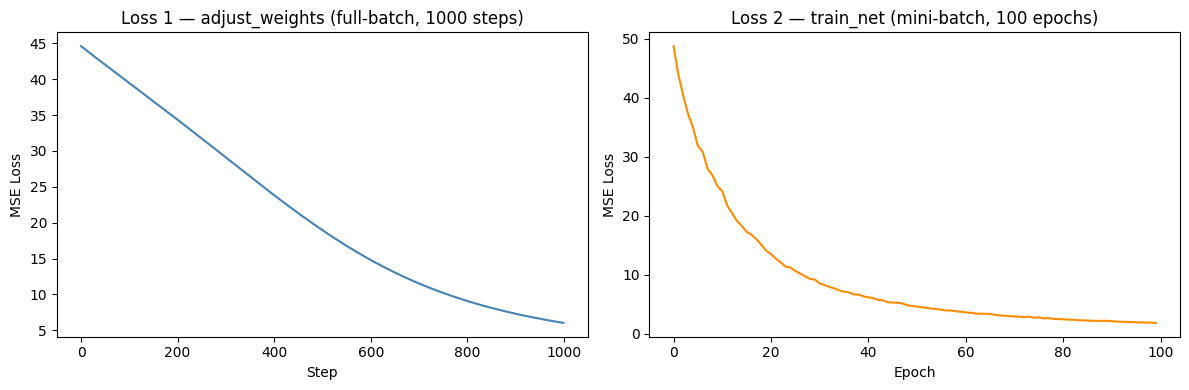

Final Loss (adjust_weights): 6.040599
Final Loss (train_net)     : 1.833914


In [24]:
np.random.seed(12345)

n = 1000
d = 4

k = np.random.randint(0, 10, (d, 1))
x = np.random.normal(0, 1, (n, d))
y = np.dot(x, k) + 0.1 + np.random.normal(0, 0.01, (n, 1))

# ── Method 1: full-batch gradient descent via adjust_weights
nn1 = NeuralNet(d, 1, [18, 12])
loss_1 = [nn1.adjust_weights(x, y) for _ in range(1000)]

# ── Method 2: mini-batch training via train_net
nn2 = NeuralNet(d, 1, [18, 12])
loss_2, _ = nn2.train_net(x, y, batch_size=32, epochs=100,
                           learning_rate=1e-4, use_validation_data=False, verbose=False)

# ── Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(loss_1, color="steelblue")
axes[0].set_title("Loss 1 — adjust_weights (full-batch, 1000 steps)")
axes[0].set_xlabel("Step"); axes[0].set_ylabel("MSE Loss")

axes[1].plot(loss_2, color="darkorange")
axes[1].set_title("Loss 2 — train_net (mini-batch, 100 epochs)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MSE Loss")

plt.tight_layout()
plt.show()

print("Final Loss (adjust_weights):", round(loss_1[-1], 6))
print("Final Loss (train_net)     :", round(loss_2[-1], 6))

## Real test and preprocessing
### 8) Dataset 1: Wine — with and without scaling

We train two networks over **3 independent runs** and compare accuracy and loss curves.
Scaling is done with `MinMaxScaler` fitted **only on the training fold** to avoid data leakage.

The Wine dataset has 3 classes (1, 2, 3). We use **one-hot encoding** on the target and a **sigmoid output** layer with 3 units so the network treats it as multi-label classification.

Run 1:  final_acc_scaled=0.417  final_acc_unscaled=0.389
Run 2:  final_acc_scaled=0.694  final_acc_unscaled=0.389
Run 3:  final_acc_scaled=0.333  final_acc_unscaled=0.250


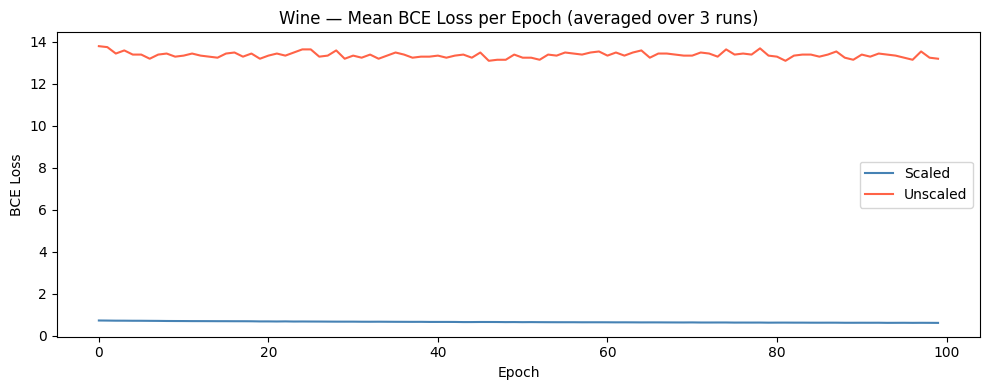

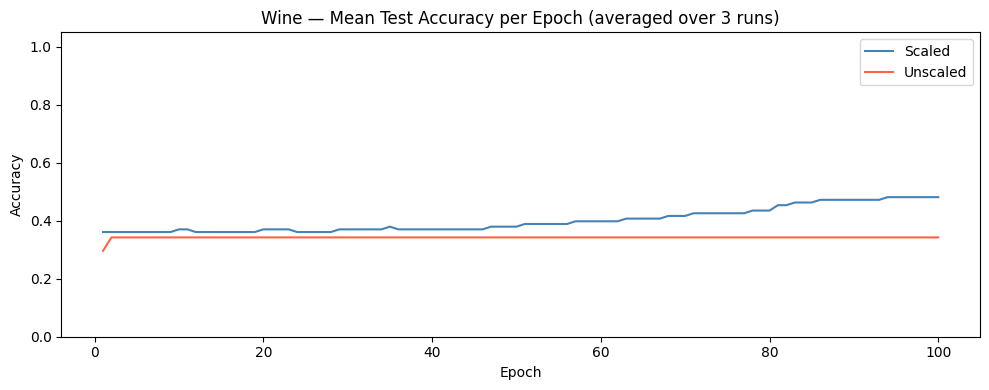

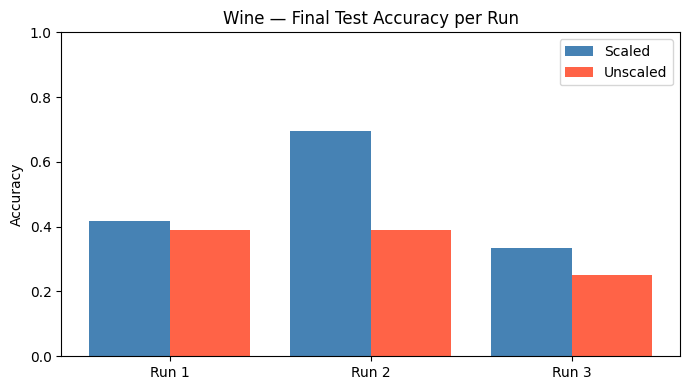


Mean final accuracy  SCALED  : 0.481
Mean final accuracy  UNSCALED: 0.343


In [25]:
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

# ── Load Wine — drop row 0 which contains column-type markers ('r')
data_wine = pd.read_csv("wine.csv").drop(index=0).reset_index(drop=True)
data_wine = data_wine.astype(float)

X_wine = data_wine.iloc[:, :-1].to_numpy()          # 13 chemical features
y_wine_raw = data_wine.iloc[:, -1].to_numpy()        # class labels 1, 2, 3

# One-hot encode the class labels → shape (178, 3)
ohe   = preprocessing.OneHotEncoder(sparse_output=False)
Y_wine = ohe.fit_transform(y_wine_raw.reshape(-1, 1))

N_RUNS  = 3
EPOCHS  = 100
LR      = 1e-3
BATCH   = 32

acc_sc_runs, acc_un_runs   = [], []
loss_sc_all,  loss_un_all  = [], []

for run in range(N_RUNS):
    Xtr, Xte, Ytr, Yte = train_test_split(
        X_wine, Y_wine, test_size=0.2, random_state=run)

    # Fit scaler ONLY on training data — prevents data leakage
    sc = preprocessing.MinMaxScaler().fit(Xtr)
    Xtr_sc, Xte_sc = sc.transform(Xtr), sc.transform(Xte)

    # ── Scaled network
    nn_sc = NeuralNet(Xtr.shape[1], 3, [32, 16], output_activation="sigmoid")
    acc_sc_ep, loss_sc_ep = [], []
    for ep in range(EPOCHS):
        bl, _ = nn_sc.train_net(Xtr_sc, Ytr, batch_size=BATCH, epochs=1,
                                learning_rate=LR, loss_fn="bce", verbose=False)
        loss_sc_ep.extend(bl)
        acc_sc_ep.append(nn_sc.score(Xte_sc, Yte))

    # ── Unscaled network
    nn_un = NeuralNet(Xtr.shape[1], 3, [32, 16], output_activation="sigmoid")
    acc_un_ep, loss_un_ep = [], []
    for ep in range(EPOCHS):
        bl, _ = nn_un.train_net(Xtr, Ytr, batch_size=BATCH, epochs=1,
                                learning_rate=LR, loss_fn="bce", verbose=False)
        loss_un_ep.extend(bl)
        acc_un_ep.append(nn_un.score(Xte, Yte))

    acc_sc_runs.append(acc_sc_ep)
    acc_un_runs.append(acc_un_ep)
    loss_sc_all.append(loss_sc_ep)
    loss_un_all.append(loss_un_ep)
    print(f"Run {run+1}:  final_acc_scaled={acc_sc_ep[-1]:.3f}  "
          f"final_acc_unscaled={acc_un_ep[-1]:.3f}")

mean_acc_sc  = np.mean(acc_sc_runs,  axis=0)
mean_acc_un  = np.mean(acc_un_runs,  axis=0)
mean_loss_sc = np.mean(loss_sc_all,  axis=0)
mean_loss_un = np.mean(loss_un_all,  axis=0)

# ── Plot mean BCE loss
plt.figure(figsize=(10, 4))
plt.plot(mean_loss_sc, label="Scaled",   color="steelblue")
plt.plot(mean_loss_un, label="Unscaled", color="tomato")
plt.title("Wine — Mean BCE Loss per Epoch (averaged over 3 runs)")
plt.xlabel("Epoch"); plt.ylabel("BCE Loss")
plt.legend(); plt.tight_layout(); plt.show()

# ── Plot mean test accuracy
plt.figure(figsize=(10, 4))
plt.plot(range(1, EPOCHS + 1), mean_acc_sc, label="Scaled",   color="steelblue")
plt.plot(range(1, EPOCHS + 1), mean_acc_un, label="Unscaled", color="tomato")
plt.title("Wine — Mean Test Accuracy per Epoch (averaged over 3 runs)")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.ylim(0, 1.05)
plt.legend(); plt.tight_layout(); plt.show()

# ── Final accuracy bar chart comparing 3 runs
x_pos = np.arange(N_RUNS)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x_pos - 0.2, [r[-1] for r in acc_sc_runs], 0.4, label="Scaled",   color="steelblue")
ax.bar(x_pos + 0.2, [r[-1] for r in acc_un_runs], 0.4, label="Unscaled", color="tomato")
ax.set_xticks(x_pos); ax.set_xticklabels([f"Run {i+1}" for i in range(N_RUNS)])
ax.set_ylim(0, 1); ax.set_ylabel("Accuracy")
ax.set_title("Wine — Final Test Accuracy per Run")
ax.legend(); plt.tight_layout(); plt.show()

print(f"\nMean final accuracy  SCALED  : {mean_acc_sc[-1]:.3f}")
print(f"Mean final accuracy  UNSCALED: {mean_acc_un[-1]:.3f}")

## Real data and hyper-parameter tuning
### 9) Dataset 2: Mushroom

Binary classification — edible (0) vs poisonous (1). All columns are categorical.

**When hyper-parameter tuning, the parameters and network sizes we test:**

**Parameter 1:** Learning rate — values: `1e-2, 1e-3, 1e-4`

**Parameter 2:** Number of neurons in hidden layers — sizes: `[8]`, `[16, 8]`, `[32, 16]`

**Neural network sizes:** `[8]`, `[16, 8]`, `[32, 16]`

Mushroom: 8124 samples, 116 features after encoding


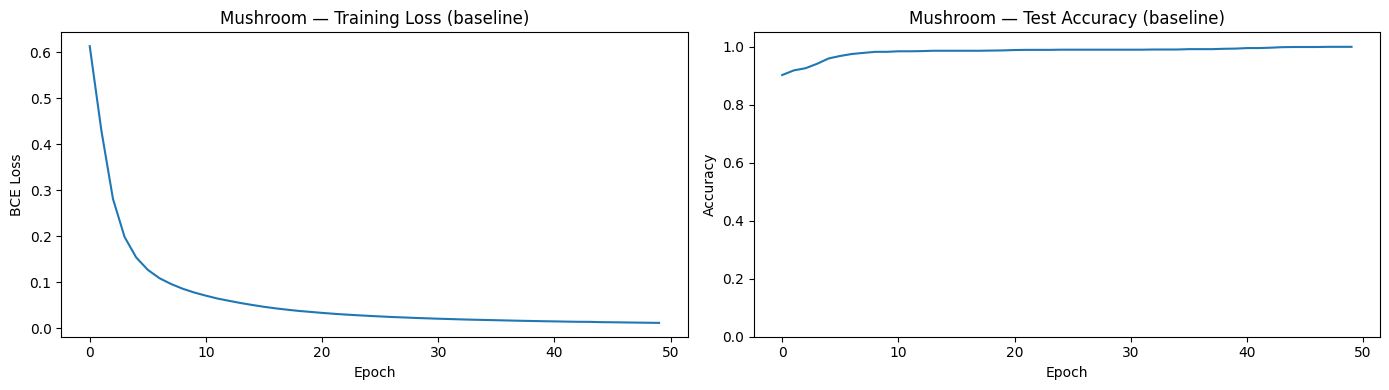

Baseline test accuracy: 1.0000


In [33]:
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

# ── Load and clean Mushroom data
data_mushroom = pd.read_csv("mushroom.csv")

# Replace '?' (missing values) with the most frequent value in each column
data_mushroom = data_mushroom.replace('?', np.nan)
for col in data_mushroom.columns:
    data_mushroom[col] = data_mushroom[col].fillna(data_mushroom[col].mode()[0])

# ── Encode target: 'p' = poisonous → 1, 'e' = edible → 0
y_mush = (data_mushroom["edible"] == 'p').astype(float).to_numpy().reshape(-1, 1)

# ── One-hot encode all feature columns
X_mush_raw = data_mushroom.drop(columns=["edible"])
encoder = preprocessing.OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_mush  = encoder.fit_transform(X_mush_raw)

# ── Scale features to [0, 1]
X_mush = preprocessing.MinMaxScaler().fit_transform(X_mush)

X_tr_m, X_te_m, Y_tr_m, Y_te_m = train_test_split(
    X_mush, y_mush, test_size=0.2, random_state=42)

print(f"Mushroom: {X_mush.shape[0]} samples, {X_mush.shape[1]} features after encoding")

# ── Helper: train epoch-by-epoch and track per-epoch test accuracy
def train_and_track(Xtr, Ytr, Xte, Yte, neurons, lr, batch_size, epochs,
                    loss_fn="bce", out_act="sigmoid"):
    model = NeuralNet(Xtr.shape[1], Ytr.shape[1], neurons, output_activation=out_act)
    losses, accs = [], []
    for ep in range(epochs):
        perm = np.random.permutation(len(Xtr))
        bl   = []
        for s in range(0, len(Xtr), batch_size):
            idx = perm[s:s + batch_size]
            bl.append(model.adjust_weights(Xtr[idx], Ytr[idx],
                                           learning_rate=lr, loss_fn=loss_fn))
        losses.append(np.mean(bl))
        accs.append(model.score(Xte, Yte))
    return losses, accs

# ── Baseline training (default parameters)
np.random.seed(42)
losses_base, accs_base = train_and_track(
    X_tr_m, Y_tr_m, X_te_m, Y_te_m, [32, 16], lr=1e-2, batch_size=64, epochs=50)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(losses_base); axes[0].set_title("Mushroom — Training Loss (baseline)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
axes[1].plot(accs_base);   axes[1].set_title("Mushroom — Test Accuracy (baseline)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_ylim(0, 1.05)
plt.tight_layout(); plt.show()
print(f"Baseline test accuracy: {accs_base[-1]:.4f}")

In [27]:
# ── Hyper-parameter grid search: learning_rate × network_size
lr_values     = [1e-2, 1e-3, 1e-4]
network_sizes = [[8], [16, 8], [32, 16]]
EPOCHS_M      = 50
BATCH_M       = 64

results_mush = {}   # key → {"losses": [...], "accuracy": float}

for lr in lr_values:
    for ns in network_sizes:
        np.random.seed(42)
        ls, ac = train_and_track(X_tr_m, Y_tr_m, X_te_m, Y_te_m,
                                 neurons=ns, lr=lr, batch_size=BATCH_M, epochs=EPOCHS_M)
        key = f"lr={lr:.0e}, layers={ns}"
        results_mush[key] = {"losses": ls, "accuracy": round(ac[-1], 4)}
        print(f"{key:35s}  ->  acc = {ac[-1]:.4f}")

best_key_m = max(results_mush, key=lambda k: results_mush[k]["accuracy"])
print(f"\nBest combination: {best_key_m}  ->  accuracy = {results_mush[best_key_m]['accuracy']}")

lr=1e-02, layers=[8]                 ->  acc = 0.9982
lr=1e-02, layers=[16, 8]             ->  acc = 1.0000
lr=1e-02, layers=[32, 16]            ->  acc = 1.0000
lr=1e-03, layers=[8]                 ->  acc = 0.9606
lr=1e-03, layers=[16, 8]             ->  acc = 0.9686
lr=1e-03, layers=[32, 16]            ->  acc = 0.9692
lr=1e-04, layers=[8]                 ->  acc = 0.8209
lr=1e-04, layers=[16, 8]             ->  acc = 0.5625
lr=1e-04, layers=[32, 16]            ->  acc = 0.7452

Best combination: lr=1e-02, layers=[16, 8]  ->  accuracy = 1.0


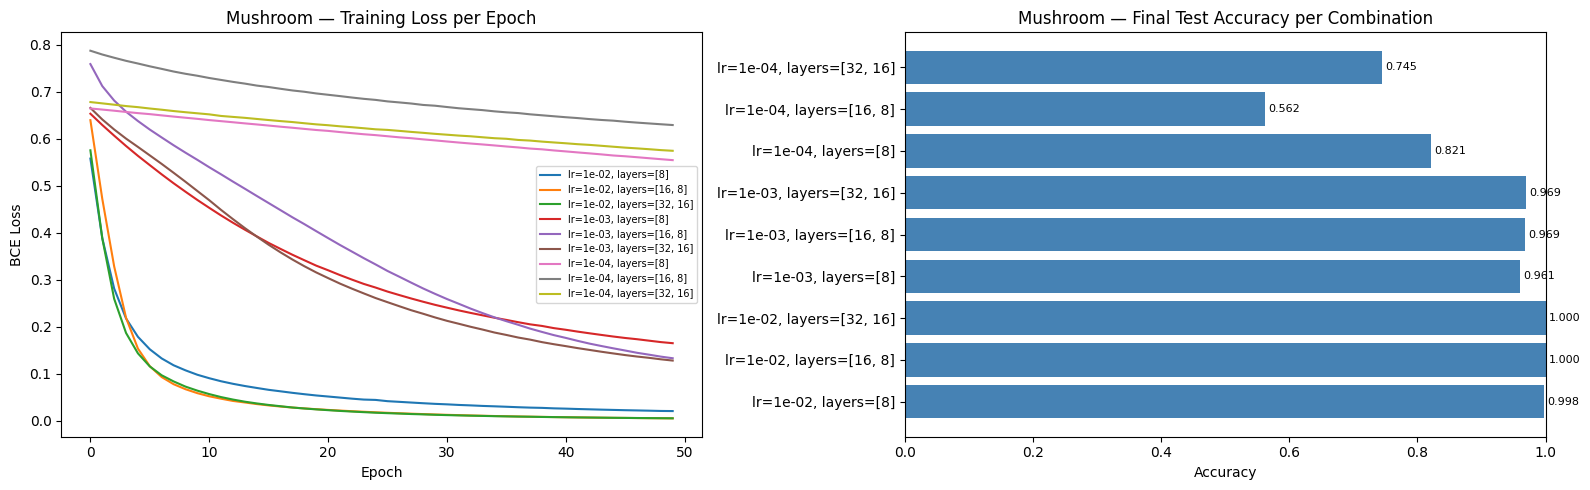

In [28]:
# ── Visualise mushroom hyper-parameter tuning results
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss curves — one line per combination
for key, res in results_mush.items():
    axes[0].plot(res["losses"], label=key)
axes[0].set_title("Mushroom — Training Loss per Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
axes[0].legend(fontsize=7)

# Test accuracy bar chart
keys = list(results_mush.keys())
accs = [results_mush[k]["accuracy"] for k in keys]
axes[1].barh(keys, accs, color="steelblue")
axes[1].set_xlim(0, 1)
axes[1].set_title("Mushroom — Final Test Accuracy per Combination")
axes[1].set_xlabel("Accuracy")
for i, v in enumerate(accs):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=8)

plt.tight_layout(); plt.show()

### 10) Dataset 3: Adult

Binary classification — predict whether income exceeds 50K.

**When hyper-parameter tuning, the parameters and network sizes we test:**

**Parameter 1:** Learning rate — values: `1e-2, 1e-3, 1e-4`

**Parameter 2:** Batch size — values: `64, 128, 256`

**Neural network sizes:** `[32, 16]`

Adult: 30000 samples, 105 features


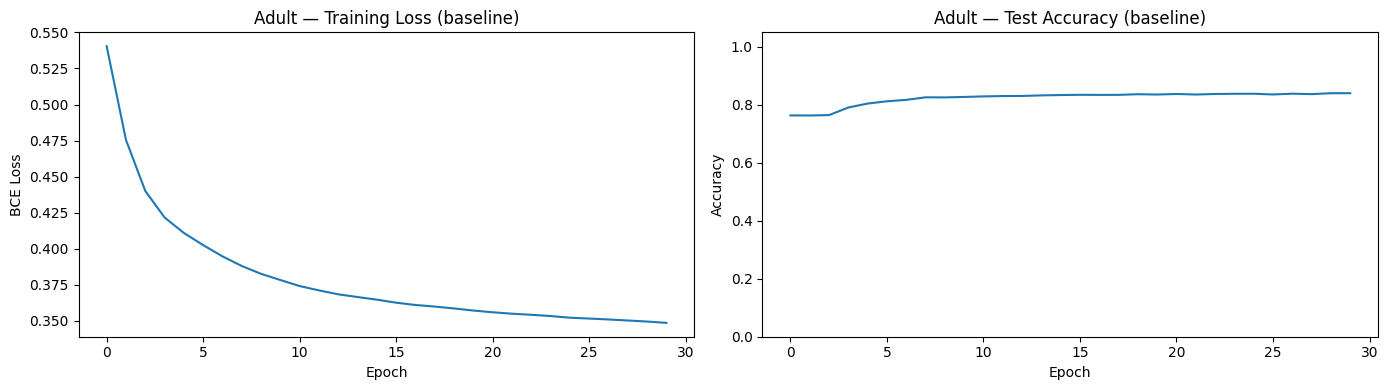

Baseline test accuracy: 0.8400


In [34]:
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

# ── Load Adult data
dataset_3 = pd.read_csv("adult.csv")

# Replace '?' with NaN
dataset_3 = dataset_3.replace('?', np.nan)

# Strip whitespace from string columns
for col in dataset_3.columns:
    if dataset_3[col].dtype == object:
        dataset_3[col] = dataset_3[col].str.strip()

# Convert numeric-looking columns to actual numeric type
for col in dataset_3.columns:
    converted = pd.to_numeric(dataset_3[col], errors='coerce')
    if converted.notna().sum() > len(dataset_3) * 0.5:
        dataset_3[col] = converted

# Safely impute missing values
for col in dataset_3.columns:
    if pd.api.types.is_numeric_dtype(dataset_3[col]):
        dataset_3[col] = dataset_3[col].fillna(dataset_3[col].median())
    else:
        dataset_3[col] = dataset_3[col].fillna(dataset_3[col].mode()[0])

# ── Target: income >50K → 1, else → 0
y_adult = (dataset_3["income"].str.strip() == ">50K").astype(float).to_numpy().reshape(-1, 1)

# ── Features: one-hot encode categoricals, MinMax scale numerics
X_raw    = dataset_3.drop(columns=["income"])
cat_cols = X_raw.select_dtypes(include="str").columns.tolist()
num_cols = X_raw.select_dtypes(exclude="str").columns.tolist()
enc        = preprocessing.OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat      = enc.fit_transform(X_raw[cat_cols])
num_scaler = preprocessing.MinMaxScaler()
X_num      = num_scaler.fit_transform(X_raw[num_cols].to_numpy())

X_adult = np.hstack([X_num, X_cat])

# Cap at 30,000 samples for speed
MAX_SAMPLES = 30000
if len(X_adult) > MAX_SAMPLES:
    idx     = np.random.choice(len(X_adult), MAX_SAMPLES, replace=False)
    X_adult = X_adult[idx]
    y_adult = y_adult[idx]

X_tr_a, X_te_a, Y_tr_a, Y_te_a = train_test_split(
    X_adult, y_adult, test_size=0.2, random_state=42)

print(f"Adult: {X_adult.shape[0]} samples, {X_adult.shape[1]} features")

# ── Baseline training
np.random.seed(42)
losses_a_base, accs_a_base = train_and_track(
    X_tr_a, Y_tr_a, X_te_a, Y_te_a, [32, 16], lr=1e-2, batch_size=128, epochs=30)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(losses_a_base); axes[0].set_title("Adult — Training Loss (baseline)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
axes[1].plot(accs_a_base);   axes[1].set_title("Adult — Test Accuracy (baseline)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_ylim(0, 1.05)
plt.tight_layout(); plt.show()
print(f"Baseline test accuracy: {accs_a_base[-1]:.4f}")

In [30]:
# ── Hyper-parameter grid search: learning_rate × batch_size ──────────────────
lr_values_a   = [1e-2, 1e-3, 1e-4]
batch_sizes_a = [64, 128, 256]
EPOCHS_A      = 30
NET_A         = [32, 16]

results_adult = {}

for lr in lr_values_a:
    for bs in batch_sizes_a:
        np.random.seed(42)
        ls, ac = train_and_track(X_tr_a, Y_tr_a, X_te_a, Y_te_a,
                                 neurons=NET_A, lr=lr, batch_size=bs, epochs=EPOCHS_A)
        key = f"lr={lr:.0e}, bs={bs}"
        results_adult[key] = {"losses": ls, "accuracy": round(ac[-1], 4)}
        print(f"{key:25s}  ->  acc = {ac[-1]:.4f}")

best_key_a = max(results_adult, key=lambda k: results_adult[k]["accuracy"])
print(f"\nBest combination: {best_key_a}  ->  accuracy = {results_adult[best_key_a]['accuracy']}")

lr=1e-02, bs=64            ->  acc = 0.8378
lr=1e-02, bs=128           ->  acc = 0.8353
lr=1e-02, bs=256           ->  acc = 0.8315
lr=1e-03, bs=64            ->  acc = 0.8140
lr=1e-03, bs=128           ->  acc = 0.7558
lr=1e-03, bs=256           ->  acc = 0.7548
lr=1e-04, bs=64            ->  acc = 0.7548
lr=1e-04, bs=128           ->  acc = 0.7548
lr=1e-04, bs=256           ->  acc = 0.7547

Best combination: lr=1e-02, bs=64  ->  accuracy = 0.8378


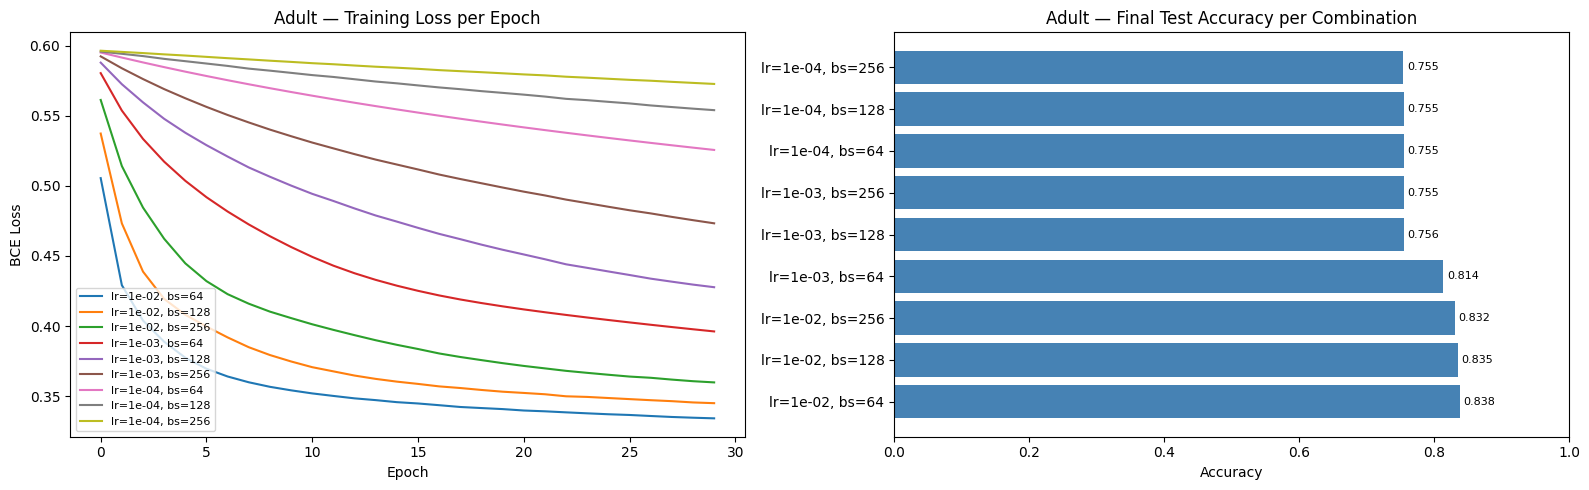

In [31]:
# ── Visualise Adult hyper-parameter tuning results
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for key, res in results_adult.items():
    axes[0].plot(res["losses"], label=key)
axes[0].set_title("Adult — Training Loss per Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
axes[0].legend(fontsize=8)

keys = list(results_adult.keys())
accs = [results_adult[k]["accuracy"] for k in keys]
axes[1].barh(keys, accs, color="steelblue")
axes[1].set_xlim(0, 1)
axes[1].set_title("Adult — Final Test Accuracy per Combination")
axes[1].set_xlabel("Accuracy")
for i, v in enumerate(accs):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=8)

plt.tight_layout(); plt.show()